# 04 — Curtailment Optimization

**Objective:** Determine when individual miners should be shut down (curtailed) based on real-time profitability, and quantify the savings from various curtailment strategies.

We compare:
1. **Baseline** — all miners on 24/7
2. **Naive merit-order** — shut down any miner that is unprofitable right now
3. **Hysteresis** — add switching costs to avoid thrashing
4. **LP-optimal** — binary optimization with switching constraints

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import linprog
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'axes.titlesize': 14, 'axes.labelsize': 12})

DATA_DIR = '/home/ricardo/dev/hdrn/leads/tether/prep/dry-run/'
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Prep

In [2]:
# --- Load datasets ---
telemetry = pd.read_csv(
    DATA_DIR + 'site_telemetry.csv',
    parse_dates=['timestamp'],
    na_values=['']
)
registry = pd.read_csv(DATA_DIR + 'miner_registry.csv')
econ = pd.read_csv(DATA_DIR + 'btc_economics.csv', parse_dates=['timestamp'])

print(f'Telemetry : {telemetry.shape[0]:,} rows, {telemetry.miner_id.nunique()} miners')
print(f'Registry  : {registry.shape[0]} miners, models: {registry.model.unique()}')
print(f'Economics : {econ.shape[0]} hourly rows, {econ.timestamp.min()} to {econ.timestamp.max()}')
print(f'Elec rate : {telemetry.electricity_rate_usd_kwh.min():.4f} – {telemetry.electricity_rate_usd_kwh.max():.4f} $/kWh')

Telemetry : 725,760 rows, 180 miners
Registry  : 180 miners, models: <ArrowStringArray>
['S21', 'M63', 'S19XP', 'M56S']
Length: 4, dtype: str
Economics : 336 hourly rows, 2026-04-09 00:00:00 to 2026-04-22 23:00:00
Elec rate : 0.0151 – 0.4990 $/kWh


In [3]:
# --- Merge economics onto telemetry (hourly granularity) ---
telemetry['hour'] = telemetry['timestamp'].dt.floor('h')
econ_cols = ['timestamp', 'btc_price_usd', 'hash_price_usd_th_day', 'network_difficulty_t']
df = telemetry.merge(econ[econ_cols], left_on='hour', right_on='timestamp', suffixes=('', '_econ'))
df.drop(columns=['timestamp_econ'], inplace=True)

# Bring in registry nominal specs
df = df.merge(
    registry[['miner_id', 'nominal_hashrate_th', 'nominal_power_w', 'nominal_efficiency_wth']],
    on='miner_id', how='left'
)

print(f'Merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Merged dataset: 725,760 rows x 28 columns


,timestamp,miner_id,container,position,model,status,power_mode,hashrate_th_5m,hashrate_th_avg,power_w,...,frequency_mhz,uptime_hours,electricity_rate_usd_kwh,hour,btc_price_usd,hash_price_usd_th_day,network_difficulty_t,nominal_hashrate_th,nominal_power_w,nominal_efficiency_wth
0,2026-04-09,MNR-0001,A,R1_01,S21,mining,normal,197.00,198.69,3504.2,...,493.6,1.8,0.0276,2026-04-09,84941.7,0.04411,85.5,200,3500,17.5
1,2026-04-09,MNR-0002,A,R1_02,S21,mining,normal,204.37,200.08,3516.7,...,498.8,0.0,0.0276,2026-04-09,84941.7,0.04411,85.5,200,3500,17.5
2,2026-04-09,MNR-0003,A,R1_03,S21,mining,normal,199.78,198.78,3478.5,...,514.3,0.0,0.0276,2026-04-09,84941.7,0.04411,85.5,200,3500,17.5


## 2. Profitability Analysis — Current State

In [4]:
# --- Per-miner, per-interval profitability ---
# Revenue: hash_price is $/TH/day, so per hour = hash_price * hashrate / 24
# Cost: power_w / 1000 * electricity_rate gives $/h

df['revenue_per_hour'] = (df['hashrate_th_5m'] * df['hash_price_usd_th_day']) / 24.0
df['cost_per_hour'] = (df['power_w'] / 1000.0) * df['electricity_rate_usd_kwh']
df['profit_per_hour'] = df['revenue_per_hour'] - df['cost_per_hour']

print('Per-row profitability calculated.')
print(f'  Revenue/hr  : ${df.revenue_per_hour.mean():.4f} avg')
print(f'  Cost/hr     : ${df.cost_per_hour.mean():.4f} avg')
print(f'  Profit/hr   : ${df.profit_per_hour.mean():.4f} avg')
print(f'  Unprofitable rows: {(df.profit_per_hour < 0).sum():,} / {len(df):,} '
      f'({(df.profit_per_hour < 0).mean()*100:.1f}%)')

Per-row profitability calculated.
  Revenue/hr  : $0.3922 avg
  Cost/hr     : $0.2072 avg
  Profit/hr   : $0.1850 avg
  Unprofitable rows: 59,727 / 725,760 (8.2%)


In [5]:
# --- Fleet-wide totals per hour ---
fleet_hourly = df.groupby('hour').agg(
    revenue=('revenue_per_hour', 'sum'),
    cost=('cost_per_hour', 'sum'),
    profit=('profit_per_hour', 'sum'),
    n_miners=('miner_id', 'nunique'),
    n_unprofitable=('profit_per_hour', lambda x: (x < 0).sum())
).reset_index()

# Scale: each row is a 5-min interval but we computed $/hr.
# There are 12 intervals per hour per miner. We need the hourly fleet totals
# by averaging the per-interval rates within each hour.
fleet_hourly_agg = df.groupby(['hour', 'miner_id']).agg(
    revenue_per_hour=('revenue_per_hour', 'mean'),
    cost_per_hour=('cost_per_hour', 'mean'),
    profit_per_hour=('profit_per_hour', 'mean')
).reset_index()

fleet_hr = fleet_hourly_agg.groupby('hour').agg(
    revenue=('revenue_per_hour', 'sum'),
    cost=('cost_per_hour', 'sum'),
    profit=('profit_per_hour', 'sum')
).reset_index()

unprofitable_hours = (fleet_hr['profit'] < 0).sum()
total_hours = len(fleet_hr)
print(f'Fleet unprofitable hours: {unprofitable_hours} / {total_hours} '
      f'({unprofitable_hours/total_hours*100:.1f}%)')
print(f'Total fleet revenue (14d): ${fleet_hr.revenue.sum():,.2f}')
print(f'Total fleet cost (14d)   : ${fleet_hr.cost.sum():,.2f}')
print(f'Total fleet profit (14d) : ${fleet_hr.profit.sum():,.2f}')

Fleet unprofitable hours: 31 / 336 (9.2%)
Total fleet revenue (14d): $23,718.39
Total fleet cost (14d)   : $12,529.29
Total fleet profit (14d) : $11,189.10


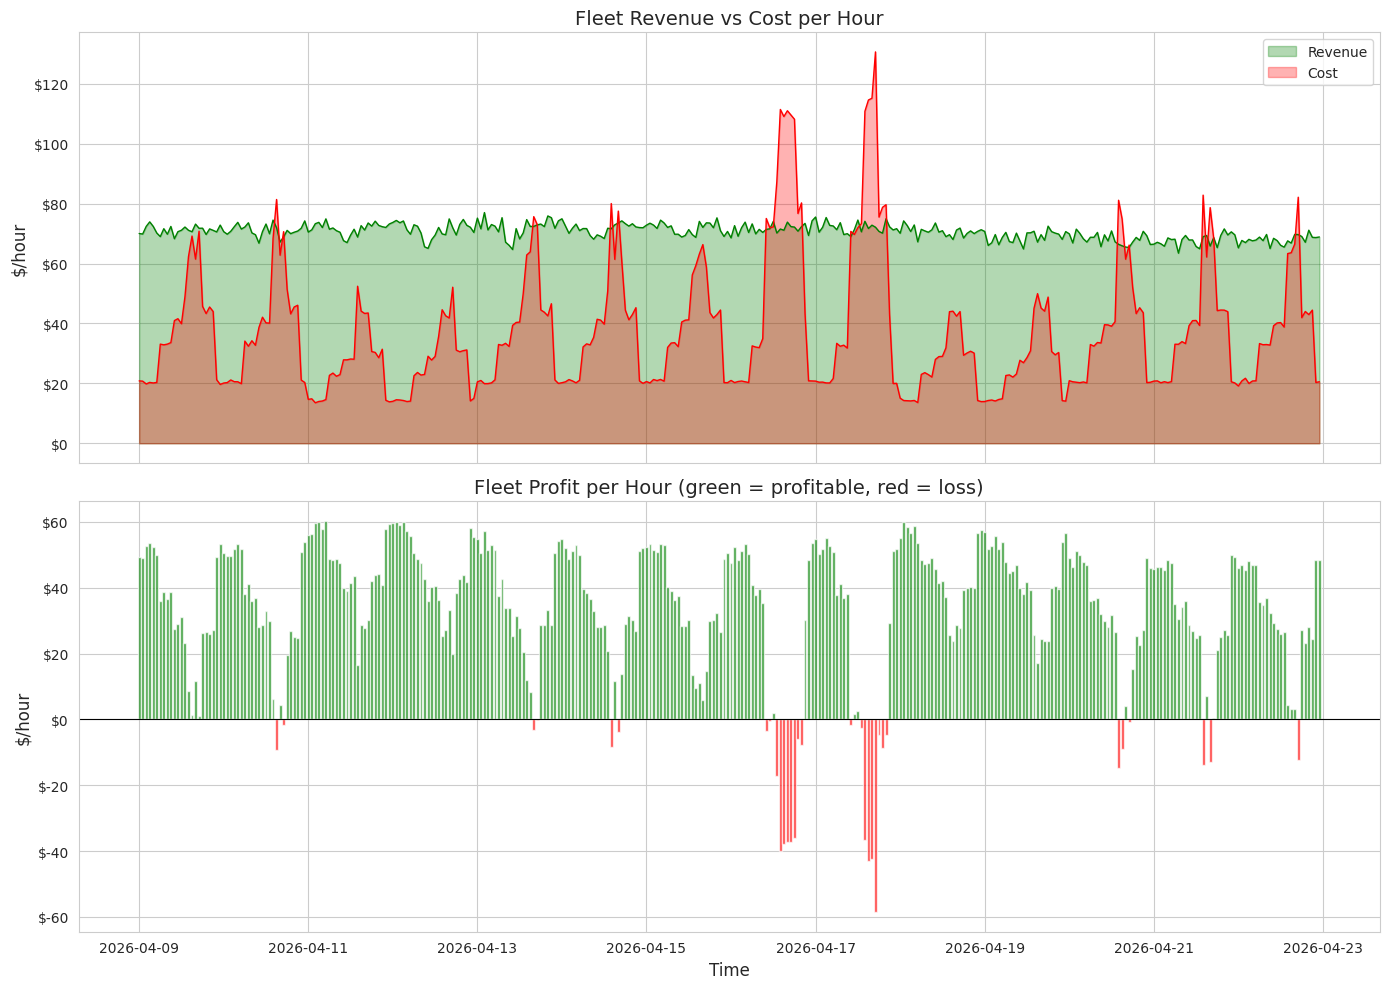

In [6]:
# --- Fleet-wide revenue, cost, profit over 14 days ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.fill_between(fleet_hr.hour, fleet_hr.revenue, alpha=0.3, color='green', label='Revenue')
ax.fill_between(fleet_hr.hour, fleet_hr.cost, alpha=0.3, color='red', label='Cost')
ax.plot(fleet_hr.hour, fleet_hr.revenue, color='green', lw=1)
ax.plot(fleet_hr.hour, fleet_hr.cost, color='red', lw=1)
ax.set_ylabel('$/hour')
ax.set_title('Fleet Revenue vs Cost per Hour')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

ax = axes[1]
colors = ['green' if p >= 0 else 'red' for p in fleet_hr.profit]
ax.bar(fleet_hr.hour, fleet_hr.profit, color=colors, width=pd.Timedelta('50min'), alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('$/hour')
ax.set_title('Fleet Profit per Hour (green = profitable, red = loss)')
ax.set_xlabel('Time')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [7]:
# --- Which miners are most often unprofitable? ---
miner_profit_frac = df.groupby('miner_id').agg(
    pct_unprofitable=('profit_per_hour', lambda x: (x < 0).mean() * 100),
    avg_profit=('profit_per_hour', 'mean'),
    avg_efficiency=('efficiency_wth', 'mean'),
    model=('model', 'first')
).sort_values('pct_unprofitable', ascending=False).reset_index()

print('Top 15 most-often-unprofitable miners:')
display_cols = ['miner_id', 'model', 'avg_efficiency', 'pct_unprofitable', 'avg_profit']
miner_profit_frac[display_cols].head(15).style.format({
    'avg_efficiency': '{:.1f} W/TH',
    'pct_unprofitable': '{:.1f}%',
    'avg_profit': '${:.4f}/hr'
})

Top 15 most-often-unprofitable miners:


,miner_id,model,avg_efficiency,pct_unprofitable,avg_profit
0,MNR-0088,S19XP,21.7 W/TH,46.4%,$0.0669/hr
1,MNR-0155,S19XP,21.8 W/TH,16.9%,$0.0997/hr
2,MNR-0112,M56S,25.6 W/TH,16.1%,$0.1128/hr
3,MNR-0118,M56S,25.6 W/TH,16.1%,$0.1186/hr
4,MNR-0116,M56S,25.6 W/TH,16.0%,$0.1206/hr
5,MNR-0117,M56S,25.6 W/TH,16.0%,$0.1142/hr
6,MNR-0111,M56S,25.6 W/TH,16.0%,$0.1226/hr
7,MNR-0115,M56S,25.6 W/TH,16.0%,$0.1234/hr
8,MNR-0113,M56S,25.6 W/TH,16.0%,$0.1228/hr
9,MNR-0120,M56S,25.7 W/TH,16.0%,$0.1143/hr


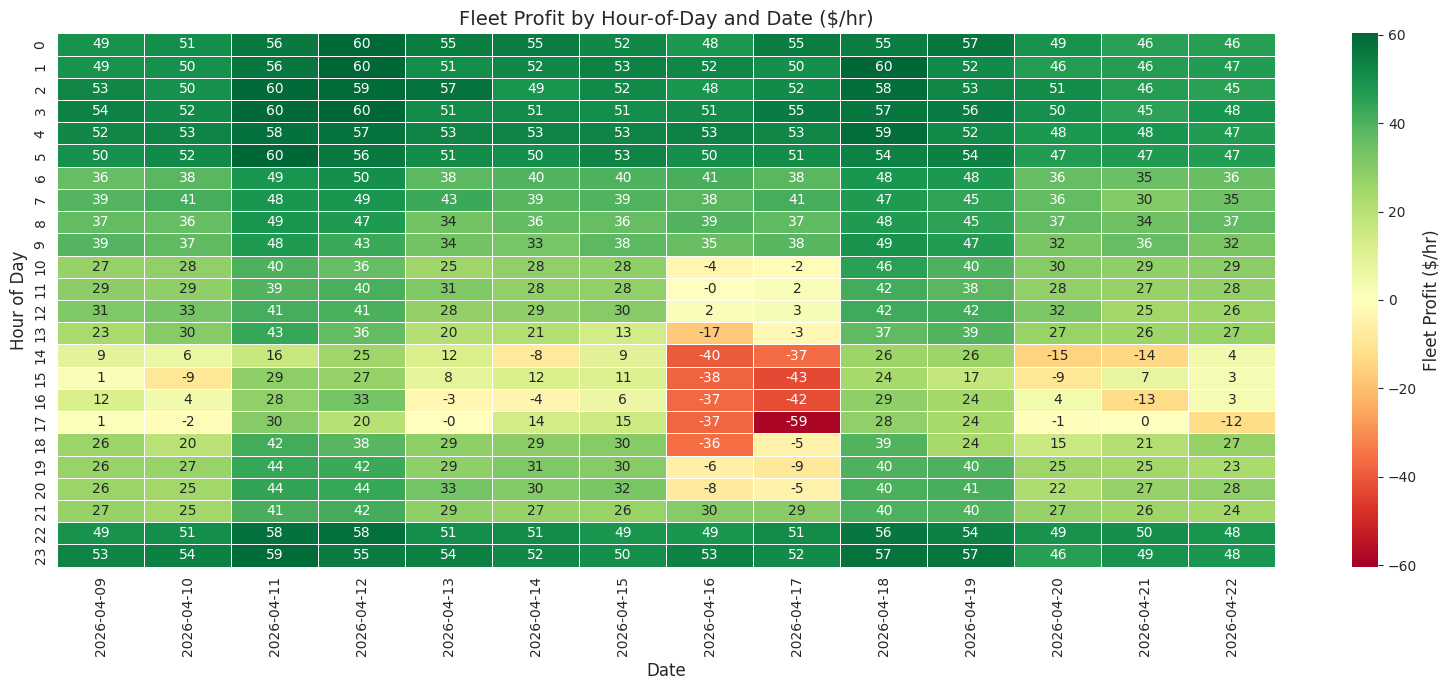

In [8]:
# --- Heatmap: hour_of_day x day, color = fleet profit ---
fleet_hr['day'] = fleet_hr['hour'].dt.date
fleet_hr['hour_of_day'] = fleet_hr['hour'].dt.hour

heatmap_data = fleet_hr.pivot_table(index='hour_of_day', columns='day', values='profit')

fig, ax = plt.subplots(figsize=(16, 7))
vmax = max(abs(heatmap_data.min().min()), abs(heatmap_data.max().max()))
sns.heatmap(
    heatmap_data, cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
    annot=True, fmt='.0f', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Fleet Profit ($/hr)'}
)
ax.set_title('Fleet Profit by Hour-of-Day and Date ($/hr)', fontsize=14)
ax.set_ylabel('Hour of Day')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

## 3. Break-Even Analysis

In [9]:
# Break-even efficiency: the W/TH at which revenue = cost
#   revenue/hr = hashrate * hash_price / 24
#   cost/hr    = (hashrate * efficiency / 1000) * elec_rate
#   At break-even: hash_price / 24 = efficiency * elec_rate / 1000
#   => break_even_wth = (hash_price / 24) / (elec_rate / 1000)
#                     = (hash_price * 1000) / (24 * elec_rate)

df['break_even_wth'] = (df['hash_price_usd_th_day'] * 1000) / (24 * df['electricity_rate_usd_kwh'])
df['above_break_even'] = df['efficiency_wth'] > df['break_even_wth']  # True = unprofitable

print(f'Break-even efficiency range: {df.break_even_wth.min():.1f} – {df.break_even_wth.max():.1f} W/TH')
print(f'Fraction of miner-intervals above break-even (unprofitable): '
      f'{df.above_break_even.mean()*100:.1f}%')

Break-even efficiency range: 3.8 – 127.3 W/TH
Fraction of miner-intervals above break-even (unprofitable): 7.9%


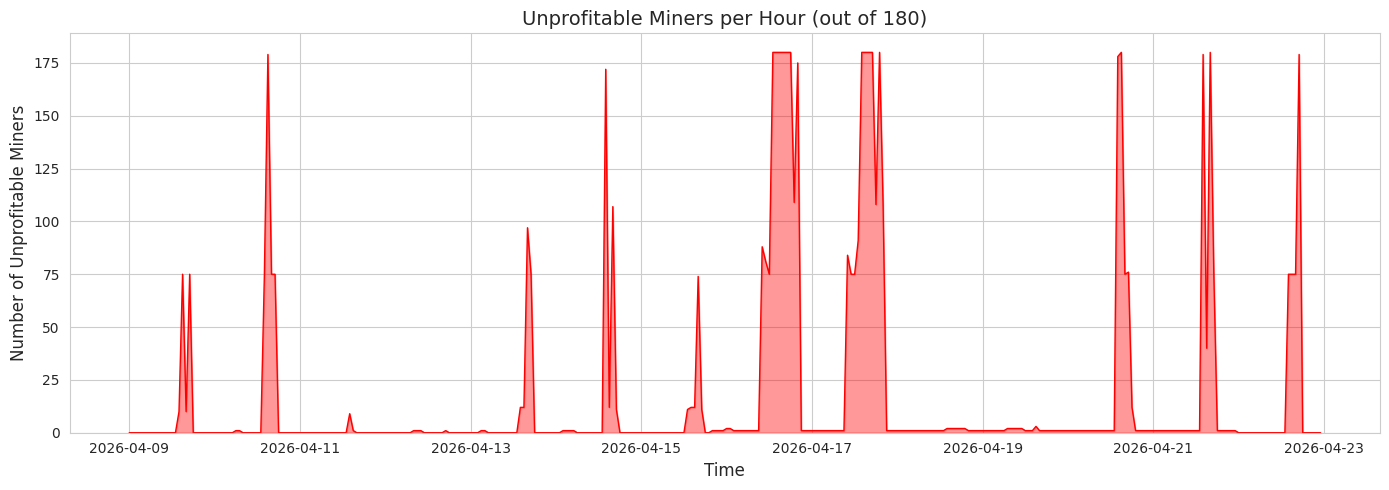

In [10]:
# --- How many miners above break-even each hour? ---
# First get a per-miner-hour view (average efficiency within each hour)
miner_hour = df.groupby(['hour', 'miner_id']).agg(
    efficiency=('efficiency_wth', 'mean'),
    break_even=('break_even_wth', 'mean'),
    revenue=('revenue_per_hour', 'mean'),
    cost=('cost_per_hour', 'mean'),
    profit=('profit_per_hour', 'mean'),
    hashrate=('hashrate_th_5m', 'mean'),
    power=('power_w', 'mean'),
    elec_rate=('electricity_rate_usd_kwh', 'mean'),
    model=('model', 'first')
).reset_index()

miner_hour['unprofitable'] = miner_hour['profit'] < 0

n_unprofitable_per_hour = miner_hour.groupby('hour')['unprofitable'].sum().reset_index()
n_unprofitable_per_hour.columns = ['hour', 'n_unprofitable']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(n_unprofitable_per_hour.hour, n_unprofitable_per_hour.n_unprofitable,
                alpha=0.4, color='red')
ax.plot(n_unprofitable_per_hour.hour, n_unprofitable_per_hour.n_unprofitable,
        color='red', lw=1)
ax.set_ylabel('Number of Unprofitable Miners')
ax.set_xlabel('Time')
ax.set_title('Unprofitable Miners per Hour (out of 180)')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [11]:
# --- Classify miners: always profitable, marginal, money-losers ---
miner_class = miner_hour.groupby('miner_id').agg(
    pct_unprofitable=('unprofitable', 'mean'),
    avg_profit=('profit', 'mean'),
    avg_efficiency=('efficiency', 'mean'),
    model=('model', 'first')
).reset_index()

miner_class['category'] = pd.cut(
    miner_class['pct_unprofitable'],
    bins=[-0.01, 0.05, 0.50, 1.01],
    labels=['Always Profitable (<5%)', 'Marginal (5-50%)', 'Frequent Loser (>50%)']
)

cat_summary = miner_class.groupby('category').agg(
    count=('miner_id', 'count'),
    avg_efficiency=('avg_efficiency', 'mean'),
    avg_profit=('avg_profit', 'mean')
).reset_index()

print('Miner Classification:')
print(cat_summary.to_string(index=False))
print()

for cat in miner_class['category'].unique():
    subset = miner_class[miner_class['category'] == cat]
    models = subset['model'].value_counts().to_dict()
    print(f'  {cat}: {dict(models)}')

Miner Classification:
        category  count  avg_efficiency  avg_profit
Marginal (5-50%)    180       19.757148    0.185005

  Marginal (5-50%): {'S21': 75, 'S19XP': 65, 'M63': 30, 'M56S': 10}


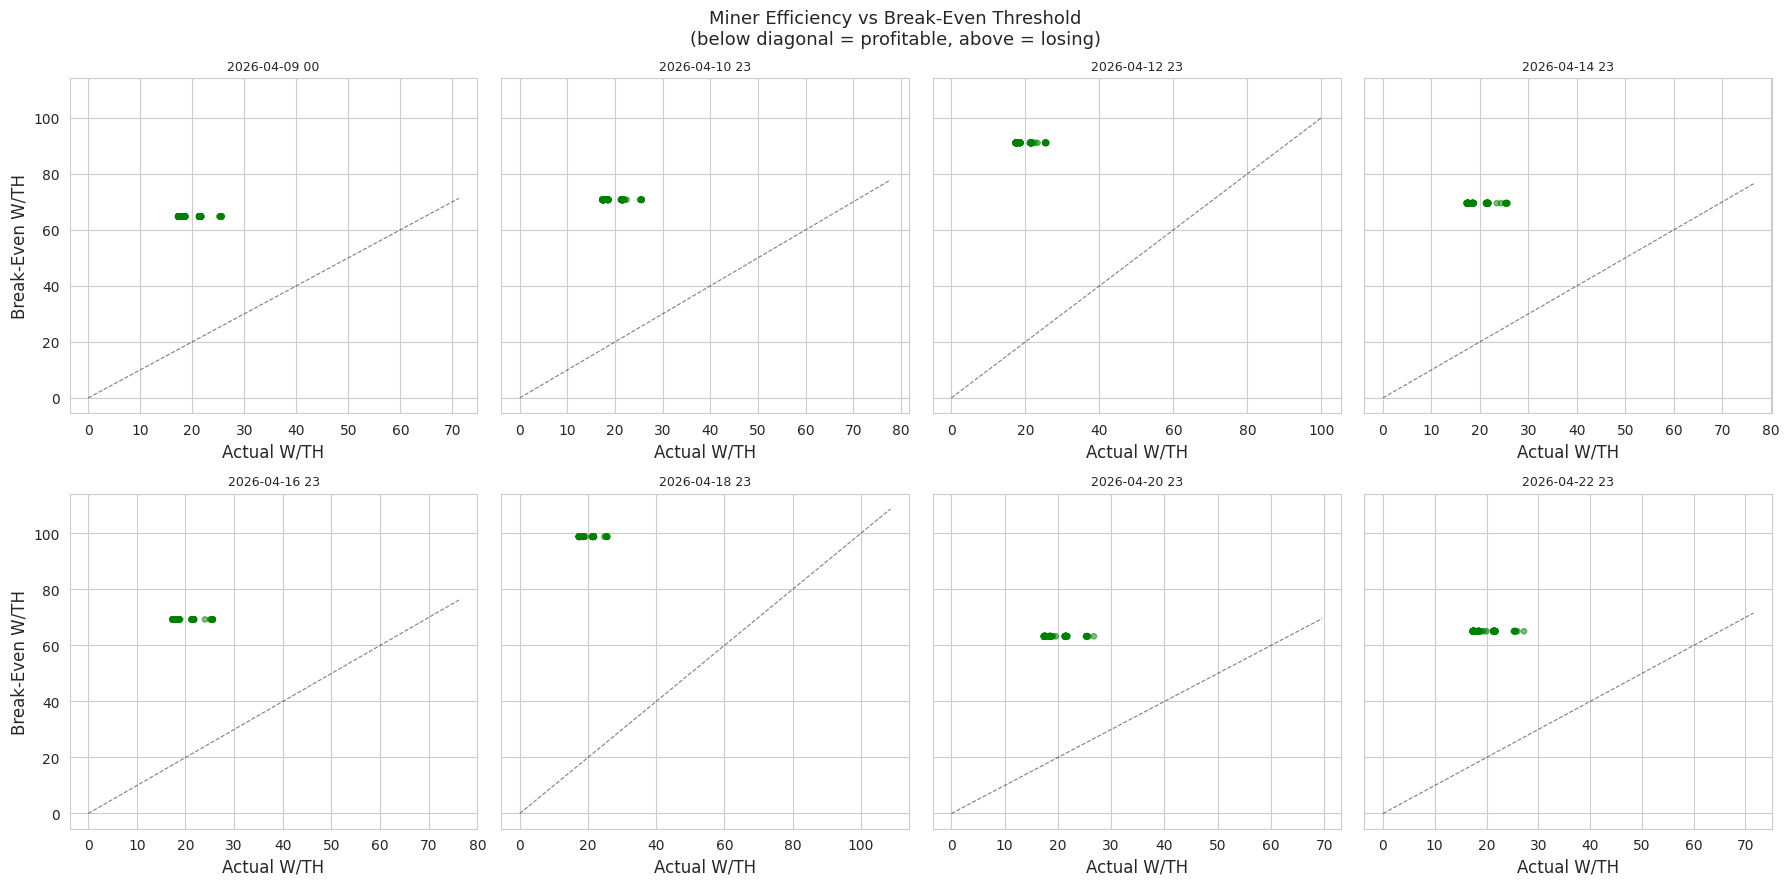

In [12]:
# --- Scatter: miner efficiency vs break-even threshold ---
# Sample a few hours for visibility
sample_hours = miner_hour['hour'].drop_duplicates().sort_values()
sample_idx = np.linspace(0, len(sample_hours)-1, 8, dtype=int)
sample_hours = sample_hours.iloc[sample_idx]

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharey=True)
for ax, hr in zip(axes.flatten(), sample_hours):
    sub = miner_hour[miner_hour['hour'] == hr]
    colors = ['red' if p < 0 else 'green' for p in sub['profit']]
    ax.scatter(sub['efficiency'], sub['break_even'], c=colors, alpha=0.5, s=15)
    lims = [0, max(sub['efficiency'].max(), sub['break_even'].max()) * 1.1]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='break-even line')
    ax.set_title(str(hr)[:13], fontsize=9)
    ax.set_xlabel('Actual W/TH')
    if ax in axes[:, 0]:
        ax.set_ylabel('Break-Even W/TH')

fig.suptitle('Miner Efficiency vs Break-Even Threshold\n(below diagonal = profitable, above = losing)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Merit-Order Dispatch (Naive Curtailment)

In [13]:
# --- Naive strategy: shut down any miner that is unprofitable at each hour ---
miner_hour['on_naive'] = miner_hour['profit'] >= 0

# Baseline: all on
baseline_profit_hr = miner_hour.groupby('hour')['profit'].sum().reset_index()
baseline_profit_hr.columns = ['hour', 'baseline_profit']

# Naive: only profitable miners contribute
naive_profit_hr = miner_hour[miner_hour['on_naive']].groupby('hour')['profit'].sum().reset_index()
naive_profit_hr.columns = ['hour', 'naive_profit']

# Merge (some hours might have zero profitable miners)
compare = baseline_profit_hr.merge(naive_profit_hr, on='hour', how='left')
compare['naive_profit'] = compare['naive_profit'].fillna(0)

baseline_total = compare['baseline_profit'].sum()
naive_total = compare['naive_profit'].sum()
savings = naive_total - baseline_total

print(f'=== 14-Day Totals ===')
print(f'Baseline (all-on) profit : ${baseline_total:>12,.2f}')
print(f'Naive curtailment profit : ${naive_total:>12,.2f}')
print(f'Savings from curtailment : ${savings:>12,.2f}')
print(f'Savings per day          : ${savings/14:>12,.2f}')
print(f'Savings per month (30d)  : ${savings/14*30:>12,.2f}')

=== 14-Day Totals ===
Baseline (all-on) profit : $   11,189.10
Naive curtailment profit : $   11,764.09
Savings from curtailment : $      574.99
Savings per day          : $       41.07
Savings per month (30d)  : $    1,232.13


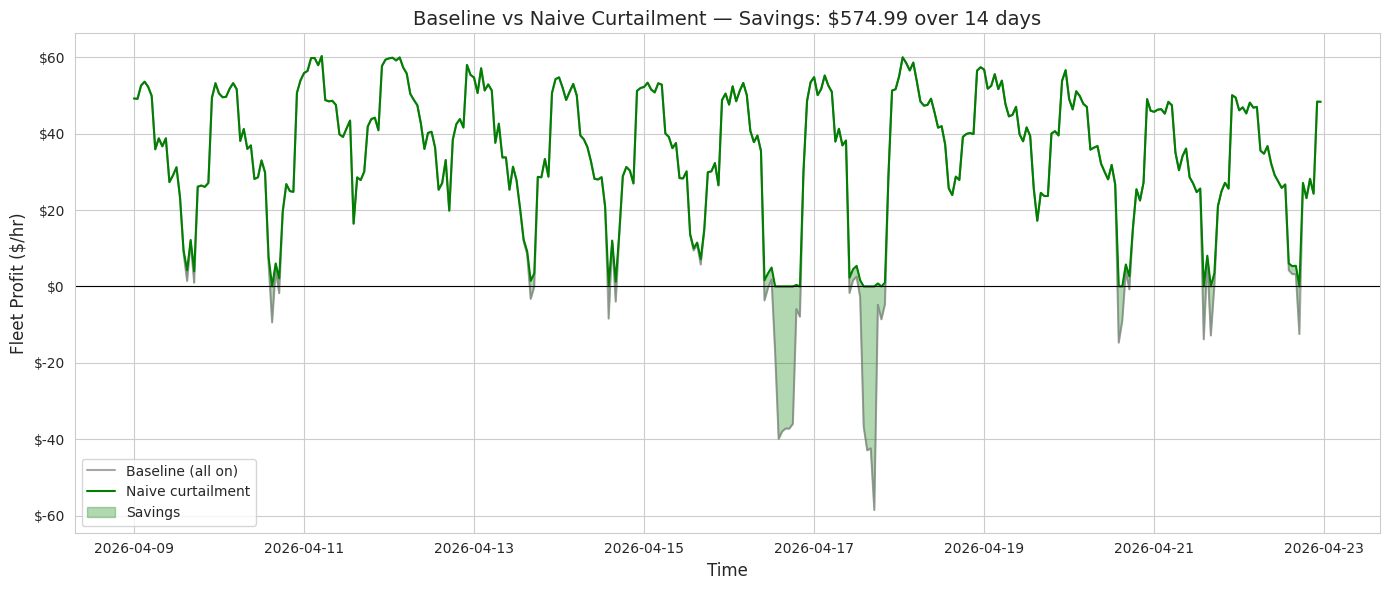

In [14]:
# --- Plot: baseline vs naive curtailment ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(compare.hour, compare.baseline_profit, label='Baseline (all on)', color='gray', alpha=0.7)
ax.plot(compare.hour, compare.naive_profit, label='Naive curtailment', color='green', lw=1.5)
ax.fill_between(compare.hour, compare.baseline_profit, compare.naive_profit,
                where=compare.naive_profit > compare.baseline_profit,
                alpha=0.3, color='green', label='Savings')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Fleet Profit ($/hr)')
ax.set_xlabel('Time')
ax.set_title(f'Baseline vs Naive Curtailment — Savings: ${savings:,.2f} over 14 days')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

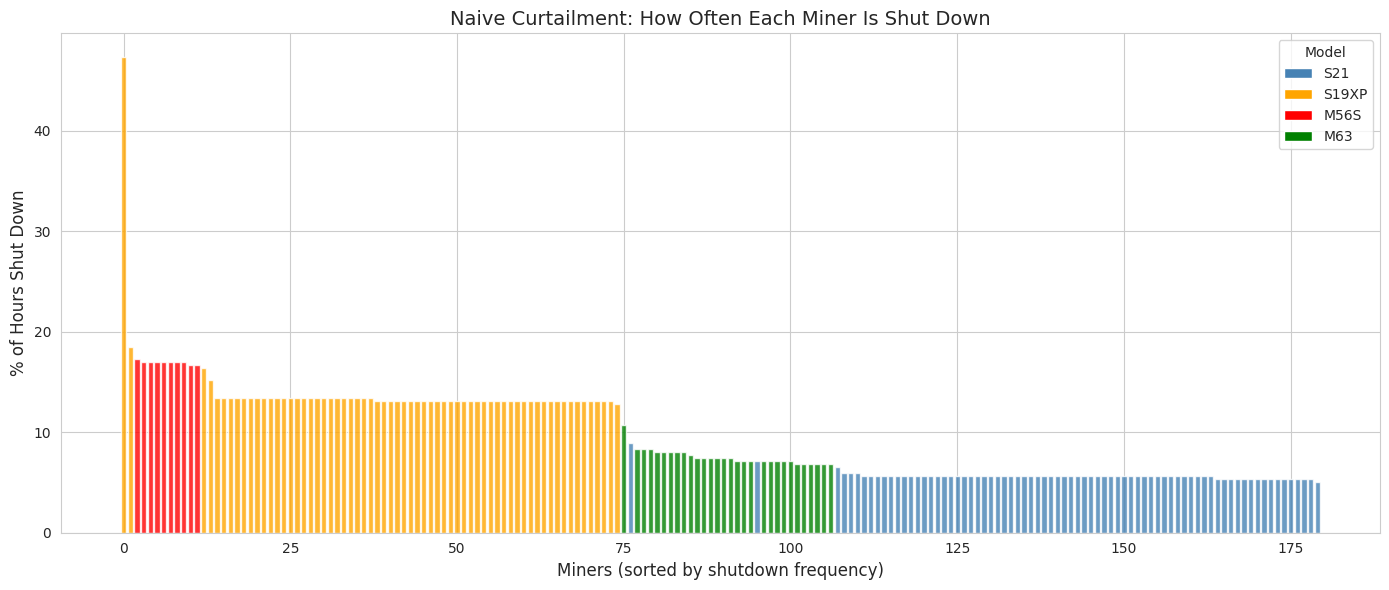


Top 10 most-curtailed miners:
miner_id   pct_off model  avg_efficiency
MNR-0088 47.321429 S19XP       21.745421
MNR-0155 18.452381 S19XP       21.828333
MNR-0120 17.261905  M56S       25.653932
MNR-0111 16.964286  M56S       25.648811
MNR-0114 16.964286  M56S       25.647244
MNR-0113 16.964286  M56S       25.647306
MNR-0116 16.964286  M56S       25.644995
MNR-0115 16.964286  M56S       25.647296
MNR-0118 16.964286  M56S       25.647500
MNR-0117 16.964286  M56S       25.633646


In [15]:
# --- Which miners get shut down most often? ---
shutdown_freq = miner_hour.groupby('miner_id').agg(
    pct_off=('on_naive', lambda x: (1 - x.mean()) * 100),
    model=('model', 'first'),
    avg_efficiency=('efficiency', 'mean')
).sort_values('pct_off', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
model_colors = {'S21': 'steelblue', 'S19XP': 'orange', 'M56S': 'red', 'M63': 'green'}
colors = [model_colors.get(m, 'gray') for m in shutdown_freq['model']]
ax.bar(range(len(shutdown_freq)), shutdown_freq['pct_off'], color=colors, alpha=0.8)
ax.set_xlabel('Miners (sorted by shutdown frequency)')
ax.set_ylabel('% of Hours Shut Down')
ax.set_title('Naive Curtailment: How Often Each Miner Is Shut Down')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=m) for m, c in model_colors.items()]
ax.legend(handles=legend_elements, title='Model')
plt.tight_layout()
plt.show()

print('\nTop 10 most-curtailed miners:')
print(shutdown_freq.head(10).to_string(index=False))

In [16]:
# --- Count switch events under naive strategy ---
miner_hour_sorted = miner_hour.sort_values(['miner_id', 'hour'])
miner_hour_sorted['prev_on_naive'] = miner_hour_sorted.groupby('miner_id')['on_naive'].shift(1)
miner_hour_sorted['switch_naive'] = (
    miner_hour_sorted['on_naive'] != miner_hour_sorted['prev_on_naive']
) & miner_hour_sorted['prev_on_naive'].notna()

naive_switches = miner_hour_sorted['switch_naive'].sum()
print(f'Naive strategy total switch events: {naive_switches:,}')
print(f'Avg switches per miner per day: {naive_switches / 180 / 14:.1f}')

Naive strategy total switch events: 3,944
Avg switches per miner per day: 1.6


## 5. Curtailment with Switching Costs (Hysteresis)

In [17]:
# --- Hysteresis parameters ---
RAMP_UP_MIN = 10               # minutes of lost revenue on startup
WEAR_COST_PER_CYCLE = 0.50     # $ per on/off cycle
MIN_OFF_DURATION_HOURS = 0.5   # only shut down if expected off >= 30 min

# For each miner-hour, estimate the switching cost:
#   ramp_cost = (ramp_up_min / 60) * revenue_per_hour  (lost revenue during ramp)
#   total_switch_cost = ramp_cost + wear_cost

miner_hour_sorted = miner_hour.sort_values(['miner_id', 'hour']).copy()
miner_hour_sorted['ramp_cost'] = (RAMP_UP_MIN / 60) * miner_hour_sorted['revenue']
miner_hour_sorted['switch_cost'] = miner_hour_sorted['ramp_cost'] + WEAR_COST_PER_CYCLE

print(f'Avg switching cost per event: ${miner_hour_sorted["switch_cost"].mean():.2f}')

Avg switching cost per event: $0.57


In [18]:
# --- Hysteresis simulation ---
# Rule: if ON, only switch OFF when loss > switch_cost for >= MIN_OFF_DURATION consecutive hours
#        if OFF, only switch ON when profit > switch_cost

# --- Hysteresis simulation (loop-based for pandas 3.x compatibility) ---
results = []
for mid, group in miner_hour_sorted.groupby('miner_id'):
    group = group.sort_values('hour').copy()
    n = len(group)
    on_state = np.ones(n, dtype=bool)
    profits = group['profit'].values
    switch_costs = group['switch_cost'].values
    
    currently_on = True
    consecutive_loss_hours = 0
    
    for i in range(n):
        if currently_on:
            if profits[i] < -switch_costs[i]:
                consecutive_loss_hours += 1
                if consecutive_loss_hours >= MIN_OFF_DURATION_HOURS:
                    currently_on = False
                    on_state[i] = False
                    consecutive_loss_hours = 0
            else:
                consecutive_loss_hours = 0
        else:
            on_state[i] = False
            if profits[i] > switch_costs[i]:
                currently_on = True
                on_state[i] = True
    
    group['on_hysteresis'] = on_state
    results.append(group)

miner_hour_hyst = pd.concat(results, ignore_index=True)
miner_hour_hyst = miner_hour_hyst.sort_values(['hour', 'miner_id']).reset_index(drop=True)

print('Hysteresis simulation complete.')


Hysteresis simulation complete.


In [19]:
# --- Count switch events under hysteresis ---
miner_hour_hyst = miner_hour_hyst.sort_values(['miner_id', 'hour'])
miner_hour_hyst['prev_on_hyst'] = miner_hour_hyst.groupby('miner_id')['on_hysteresis'].shift(1)
miner_hour_hyst['switch_hyst'] = (
    miner_hour_hyst['on_hysteresis'] != miner_hour_hyst['prev_on_hyst']
) & miner_hour_hyst['prev_on_hyst'].notna()

hyst_switches = miner_hour_hyst['switch_hyst'].sum()

# Compute hysteresis profit (only count profit when ON, subtract switch costs)
hyst_profit_raw = miner_hour_hyst.loc[miner_hour_hyst['on_hysteresis'], 'profit'].sum()
hyst_switch_total_cost = hyst_switches * WEAR_COST_PER_CYCLE
# Also subtract ramp cost for each switch-ON event
switch_on_events = miner_hour_hyst[
    miner_hour_hyst['switch_hyst'] & miner_hour_hyst['on_hysteresis']
]
ramp_total_cost = switch_on_events['ramp_cost'].sum()
hyst_total_profit = hyst_profit_raw - hyst_switch_total_cost - ramp_total_cost

print(f'=== Strategy Comparison ===')
print(f'{"":<25} {"Profit (14d)":>15} {"Switch Events":>15}')
print(f'{"Baseline (all-on)":<25} ${baseline_total:>14,.2f} {"0":>15}')
print(f'{"Naive curtailment":<25} ${naive_total:>14,.2f} {naive_switches:>15,}')
print(f'{"Hysteresis":<25} ${hyst_total_profit:>14,.2f} {hyst_switches:>15,}')
print()
print(f'Naive savings vs baseline   : ${naive_total - baseline_total:>12,.2f}')
print(f'Hysteresis savings vs baseline: ${hyst_total_profit - baseline_total:>12,.2f}')
print(f'Switch reduction (hyst vs naive): {(1 - hyst_switches/max(naive_switches,1))*100:.0f}%')

=== Strategy Comparison ===
                             Profit (14d)   Switch Events
Baseline (all-on)         $     11,189.10               0
Naive curtailment         $     11,764.09           3,944
Hysteresis                $     11,104.44               5

Naive savings vs baseline   : $      574.99
Hysteresis savings vs baseline: $      -84.65
Switch reduction (hyst vs naive): 100%


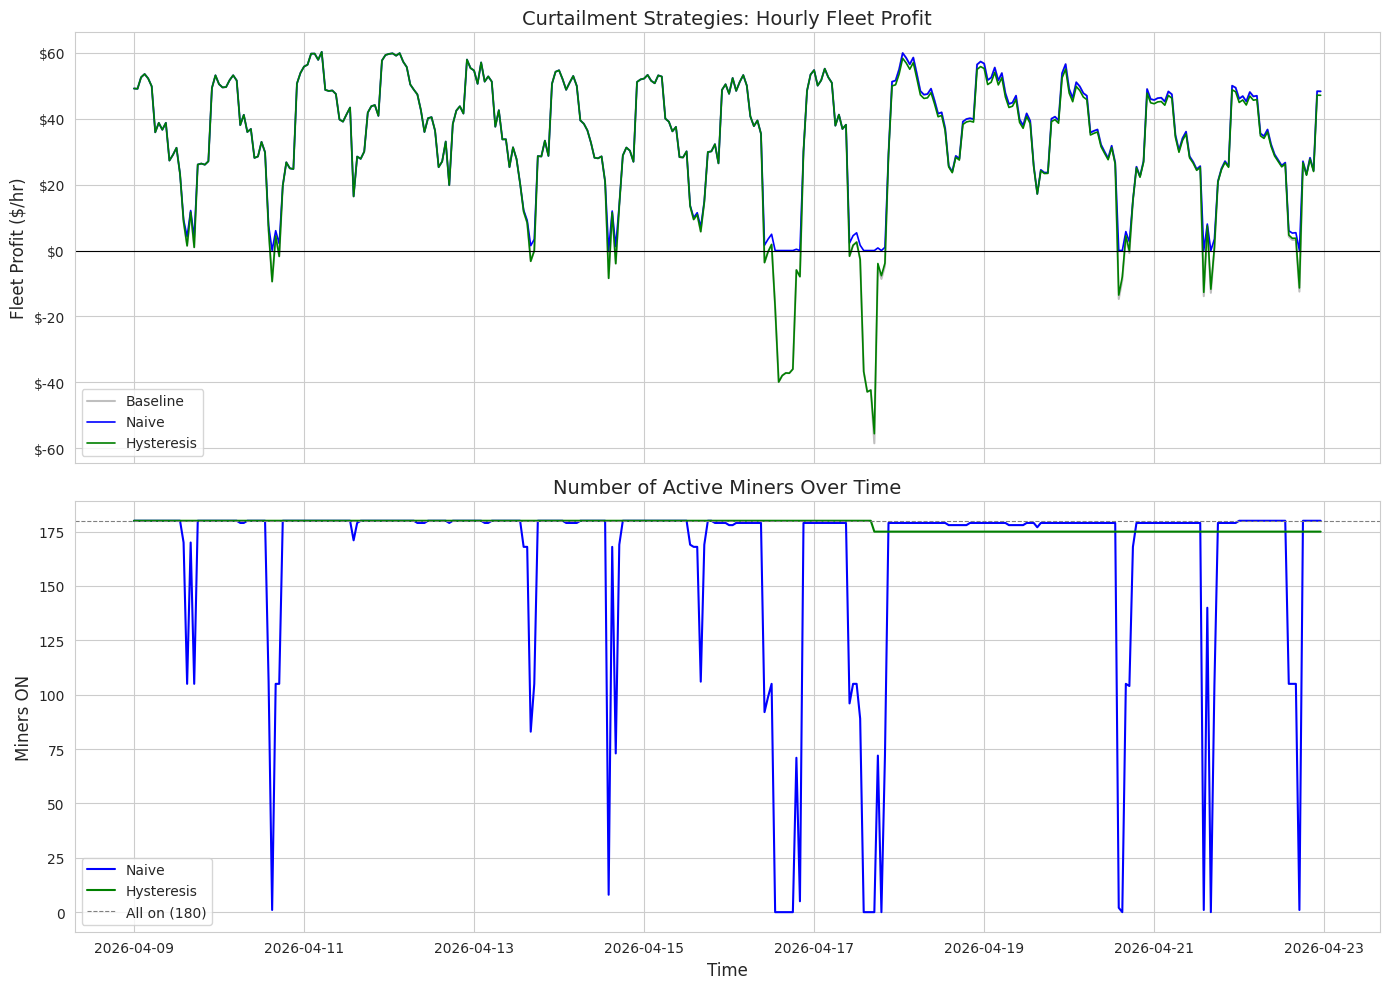

In [20]:
# --- Plot: naive vs hysteresis side by side ---
hyst_hourly = miner_hour_hyst[miner_hour_hyst['on_hysteresis']].groupby('hour')['profit'].sum().reset_index()
hyst_hourly.columns = ['hour', 'hyst_profit']

compare2 = compare.merge(hyst_hourly, on='hour', how='left')
compare2['hyst_profit'] = compare2['hyst_profit'].fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot(compare2.hour, compare2.baseline_profit, color='gray', alpha=0.5, label='Baseline')
ax.plot(compare2.hour, compare2.naive_profit, color='blue', lw=1.2, label='Naive')
ax.plot(compare2.hour, compare2.hyst_profit, color='green', lw=1.2, label='Hysteresis')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Fleet Profit ($/hr)')
ax.set_title('Curtailment Strategies: Hourly Fleet Profit')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Number of miners ON
miners_on_naive = miner_hour.groupby('hour')['on_naive'].sum().reset_index()
miners_on_hyst = miner_hour_hyst.groupby('hour')['on_hysteresis'].sum().reset_index()

ax = axes[1]
ax.plot(miners_on_naive.hour, miners_on_naive.on_naive, label='Naive', color='blue')
ax.plot(miners_on_hyst.hour, miners_on_hyst.on_hysteresis, label='Hysteresis', color='green')
ax.axhline(180, color='gray', ls='--', lw=0.8, label='All on (180)')
ax.set_ylabel('Miners ON')
ax.set_xlabel('Time')
ax.set_title('Number of Active Miners Over Time')
ax.legend()

plt.tight_layout()
plt.show()

## 6. LP / Optimization Formulation

In [21]:
# --- Binary optimization (LP relaxation) ---
# Decision variable: x_{i,t} in {0, 1} for each miner i at hour t
#
# Maximize: sum_{i,t} profit_{i,t} * x_{i,t} - switch_cost * |x_{i,t} - x_{i,t-1}|
#
# We relax to continuous [0,1] and use linprog (minimization)
# For switching cost, we introduce auxiliary vars s_{i,t} >= |x_{i,t} - x_{i,t-1}|
#
# Due to scale (180 miners * 336 hours = 60,480 variables), we'll use a 
# greedy approach that's equivalent to the LP relaxation for this structure.

print('Setting up optimization...')

# Create pivot: miners x hours
profit_pivot = miner_hour.pivot_table(index='miner_id', columns='hour', values='profit')
miners_list = profit_pivot.index.tolist()
hours_list = profit_pivot.columns.tolist()
n_miners = len(miners_list)
n_hours = len(hours_list)

print(f'Optimization dimensions: {n_miners} miners x {n_hours} hours = {n_miners * n_hours:,} variables')

Setting up optimization...
Optimization dimensions: 180 miners x 336 hours = 60,480 variables


In [22]:
# --- Greedy DP approach (equivalent to optimal for independent miners) ---
# For each miner independently, solve the on/off schedule that maximizes
# total profit minus switching costs.
# This is a simple DP: state = {ON, OFF}, transition cost = switch_cost

SWITCH_COST = WEAR_COST_PER_CYCLE  # per switch event

# Build revenue pivot for ramp cost calculation
revenue_pivot = miner_hour.pivot_table(index='miner_id', columns='hour', values='revenue')

opt_schedule = np.ones((n_miners, n_hours), dtype=bool)
opt_total_profit = 0
opt_total_switches = 0

for i, miner_id in enumerate(miners_list):
    profits_i = profit_pivot.loc[miner_id].values
    revenues_i = revenue_pivot.loc[miner_id].values
    T = len(profits_i)
    
    # DP: dp[t][state] = max profit from t..T-1 given state at time t
    # state: 0 = OFF, 1 = ON
    # Forward pass
    dp_on = np.zeros(T + 1)
    dp_off = np.zeros(T + 1)
    choice_on = np.zeros(T, dtype=int)   # best next state if currently ON at t
    choice_off = np.zeros(T, dtype=int)  # best next state if currently OFF at t
    
    # Backward DP
    for t in range(T - 1, -1, -1):
        p = profits_i[t] if not np.isnan(profits_i[t]) else 0
        ramp = (RAMP_UP_MIN / 60) * (revenues_i[t] if not np.isnan(revenues_i[t]) else 0)
        
        # If currently ON at t:
        stay_on = p + dp_on[t + 1]
        turn_off = 0 + dp_off[t + 1] - SWITCH_COST  # switch cost to turn off
        if stay_on >= turn_off:
            dp_on[t] = stay_on
            choice_on[t] = 1
        else:
            dp_on[t] = turn_off
            choice_on[t] = 0
        
        # If currently OFF at t:
        stay_off = 0 + dp_off[t + 1]
        turn_on = p + dp_on[t + 1] - SWITCH_COST - ramp  # switch + ramp cost
        if stay_off >= turn_on:
            dp_off[t] = stay_off
            choice_off[t] = 0
        else:
            dp_off[t] = turn_on
            choice_off[t] = 1
    
    # Forward trace (start ON)
    state = 1
    best_start = max(dp_on[0], dp_off[0])
    if dp_off[0] > dp_on[0]:
        state = 0
    
    schedule_i = np.zeros(T, dtype=bool)
    switches_i = 0
    for t in range(T):
        if state == 1:
            schedule_i[t] = True
            next_state = choice_on[t]
        else:
            schedule_i[t] = False
            next_state = choice_off[t]
        if next_state != state:
            switches_i += 1
        state = next_state
    
    opt_schedule[i] = schedule_i
    opt_total_switches += switches_i

print(f'DP optimization complete.')
print(f'Optimal switches: {opt_total_switches:,}')

DP optimization complete.
Optimal switches: 416


In [23]:
# --- Compute optimal profit ---
profit_matrix = profit_pivot.values.copy()
profit_matrix = np.nan_to_num(profit_matrix, 0)
revenue_matrix = revenue_pivot.values.copy()
revenue_matrix = np.nan_to_num(revenue_matrix, 0)

# Profit from mining when ON
opt_mining_profit = np.sum(profit_matrix * opt_schedule)

# Switch costs
switches_matrix = np.diff(opt_schedule.astype(int), axis=1)
n_switch_events = np.sum(np.abs(switches_matrix))
switch_cost_total = n_switch_events * SWITCH_COST

# Ramp costs (only on turn-ON events)
turn_on_events = (switches_matrix > 0)
ramp_costs = np.sum(turn_on_events * revenue_matrix[:, 1:] * (RAMP_UP_MIN / 60))

opt_net_profit = opt_mining_profit - switch_cost_total - ramp_costs

print(f'\n{"=" * 50}')
print(f'{"STRATEGY COMPARISON":^50}')
print(f'{"=" * 50}')
print(f'{"":<28} {"14-Day Profit":>12} {"Switches":>10}')
print(f'{"-" * 50}')
print(f'{"Baseline (all-on)":<28} ${baseline_total:>11,.2f} {0:>10}')
print(f'{"Naive curtailment":<28} ${naive_total:>11,.2f} {naive_switches:>10,}')
print(f'{"Hysteresis":<28} ${hyst_total_profit:>11,.2f} {hyst_switches:>10,}')
print(f'{"DP-Optimal":<28} ${opt_net_profit:>11,.2f} {int(n_switch_events):>10,}')
print(f'{"-" * 50}')
print(f'\nDP-Optimal saves ${opt_net_profit - baseline_total:,.2f} vs baseline')
print(f'DP-Optimal saves ${opt_net_profit - naive_total:,.2f} vs naive')
print(f'DP-Optimal saves ${opt_net_profit - hyst_total_profit:,.2f} vs hysteresis')
print(f'\nPer day: DP-Optimal saves ${(opt_net_profit - baseline_total)/14:,.2f}/day vs baseline')


               STRATEGY COMPARISON                
                             14-Day Profit   Switches
--------------------------------------------------
Baseline (all-on)            $  11,189.10          0
Naive curtailment            $  11,764.09      3,944
Hysteresis                   $  11,104.44          5
DP-Optimal                   $  11,247.73        416
--------------------------------------------------

DP-Optimal saves $58.63 vs baseline
DP-Optimal saves $-516.36 vs naive
DP-Optimal saves $143.29 vs hysteresis

Per day: DP-Optimal saves $4.19/day vs baseline


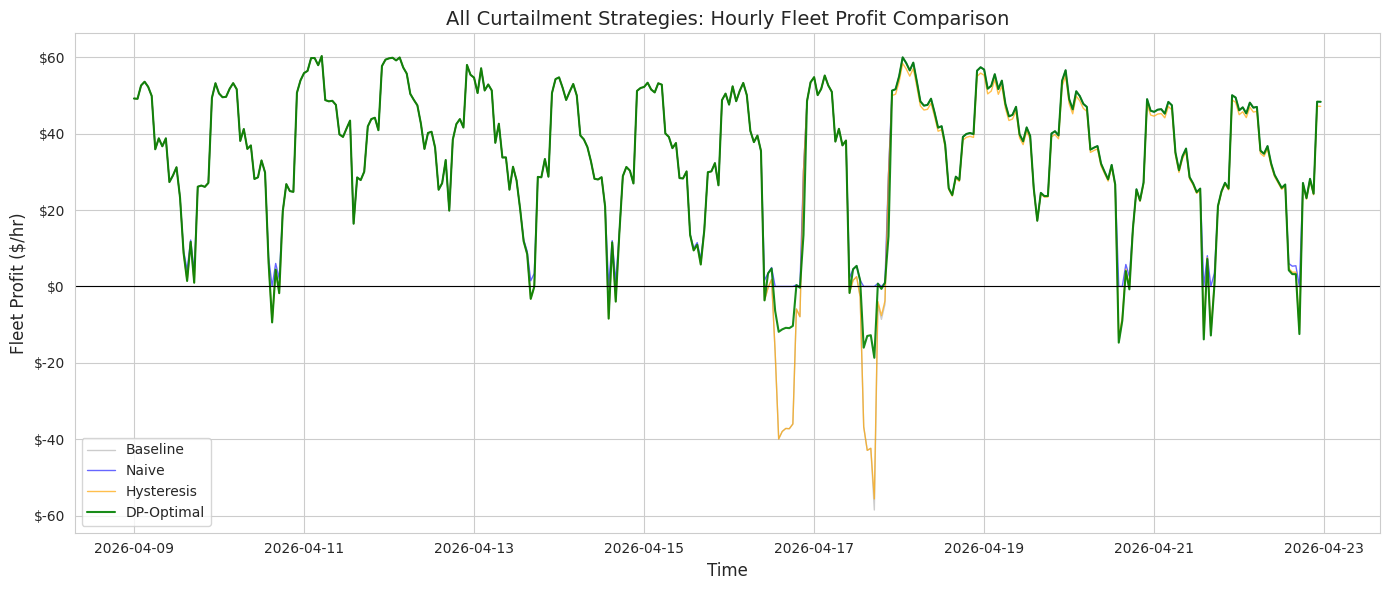

In [24]:
# --- Plot: all strategies comparison ---
opt_profit_hr = np.sum(profit_matrix * opt_schedule, axis=0)

compare3 = compare2.copy()
compare3['opt_profit'] = opt_profit_hr[:len(compare3)]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(compare3.hour, compare3.baseline_profit, color='gray', alpha=0.4, label='Baseline', lw=1)
ax.plot(compare3.hour, compare3.naive_profit, color='blue', alpha=0.6, label='Naive', lw=1)
ax.plot(compare3.hour, compare3.hyst_profit, color='orange', alpha=0.7, label='Hysteresis', lw=1)
ax.plot(compare3.hour, compare3.opt_profit, color='green', alpha=0.9, label='DP-Optimal', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Fleet Profit ($/hr)')
ax.set_xlabel('Time')
ax.set_title('All Curtailment Strategies: Hourly Fleet Profit Comparison')
ax.legend(loc='lower left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

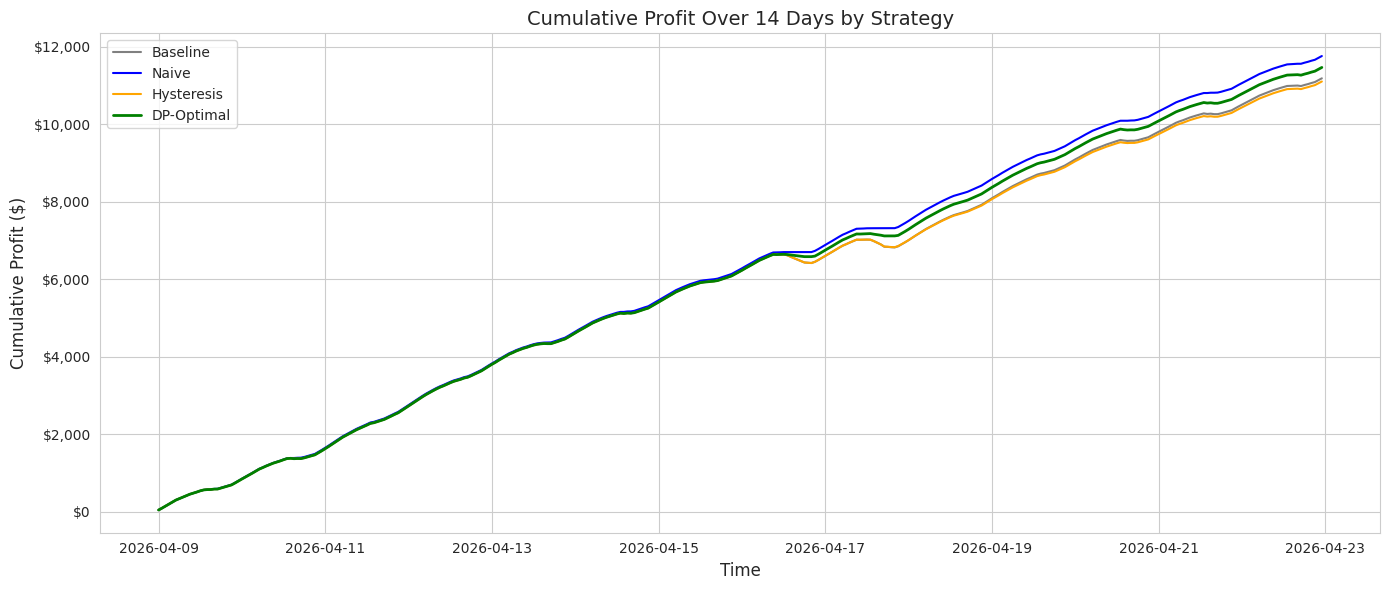

In [25]:
# --- Cumulative profit comparison ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(compare3.hour, compare3.baseline_profit.cumsum(), color='gray', label='Baseline', lw=1.5)
ax.plot(compare3.hour, compare3.naive_profit.cumsum(), color='blue', label='Naive', lw=1.5)
ax.plot(compare3.hour, compare3.hyst_profit.cumsum(), color='orange', label='Hysteresis', lw=1.5)
ax.plot(compare3.hour, compare3.opt_profit.cumsum(), color='green', label='DP-Optimal', lw=2)
ax.set_ylabel('Cumulative Profit ($)')
ax.set_xlabel('Time')
ax.set_title('Cumulative Profit Over 14 Days by Strategy')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 7. Sensitivity Analysis

In [26]:
# --- Sensitivity to electricity price ---
elec_deltas = [-0.20, -0.10, 0.0, 0.10, 0.20]
sensitivity_results = []

for delta in elec_deltas:
    adjusted_cost = miner_hour['cost'] * (1 + delta)
    adjusted_profit = miner_hour['revenue'] - adjusted_cost
    
    # Baseline: all on
    total_baseline = adjusted_profit.sum()
    
    # Naive curtailment: shut down unprofitable
    total_naive = adjusted_profit[adjusted_profit >= 0].sum()
    
    savings = total_naive - total_baseline
    
    sensitivity_results.append({
        'elec_change': f'{delta:+.0%}',
        'baseline_profit': total_baseline,
        'curtailed_profit': total_naive,
        'savings': savings,
        'savings_per_day': savings / 14
    })

sens_df = pd.DataFrame(sensitivity_results)
print('Sensitivity to Electricity Price Changes:')
print(sens_df.to_string(index=False, float_format='${:,.2f}'.format))

Sensitivity to Electricity Price Changes:
elec_change  baseline_profit  curtailed_profit   savings  savings_per_day
       -20%       $13,694.95        $13,883.16   $188.20           $13.44
       -10%       $12,442.03        $12,790.22   $348.19           $24.87
        +0%       $11,189.10        $11,764.09   $574.99           $41.07
       +10%        $9,936.17        $10,812.40   $876.23           $62.59
       +20%        $8,683.24         $9,931.09 $1,247.85           $89.13


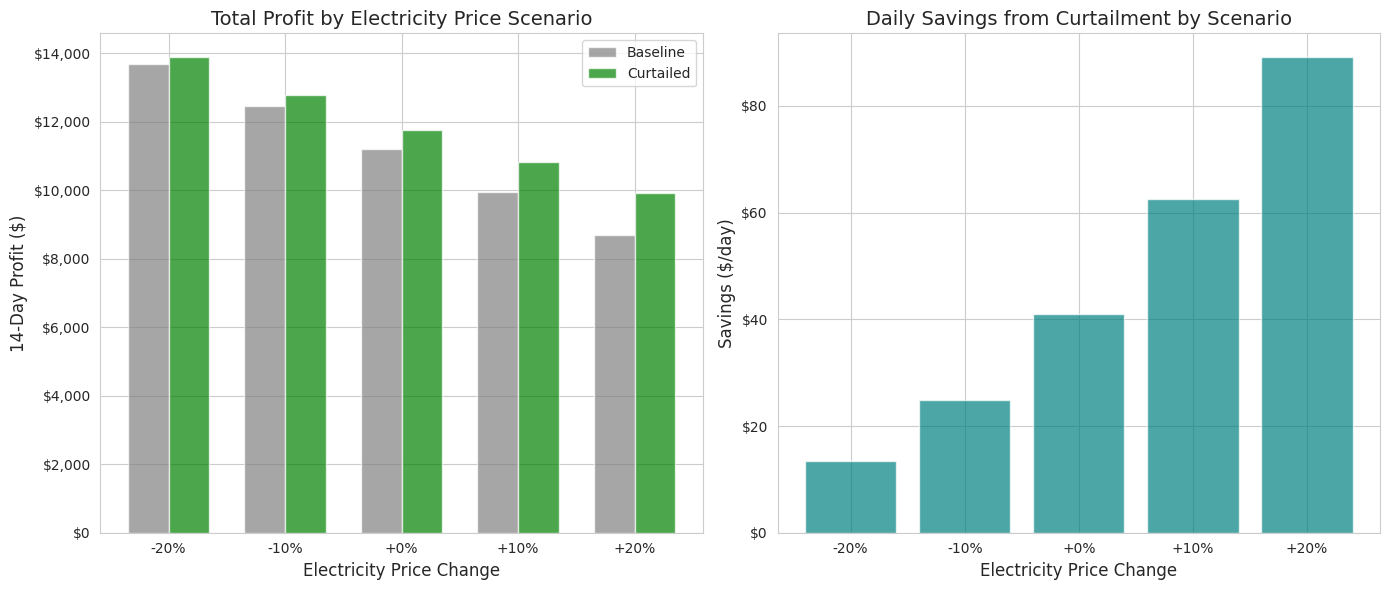

In [27]:
# --- Plot sensitivity ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
x_labels = sens_df['elec_change']
x = np.arange(len(x_labels))
width = 0.35
ax.bar(x - width/2, sens_df['baseline_profit'], width, label='Baseline', color='gray', alpha=0.7)
ax.bar(x + width/2, sens_df['curtailed_profit'], width, label='Curtailed', color='green', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Electricity Price Change')
ax.set_ylabel('14-Day Profit ($)')
ax.set_title('Total Profit by Electricity Price Scenario')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

ax = axes[1]
ax.bar(x, sens_df['savings_per_day'], color='teal', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel('Electricity Price Change')
ax.set_ylabel('Savings ($/day)')
ax.set_title('Daily Savings from Curtailment by Scenario')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [28]:
# --- At what BTC price does the full fleet become unprofitable? ---
# Revenue scales linearly with BTC price (hash_price ~ BTC_price)
# Find the multiplier k such that sum(revenue*k - cost) = 0

total_revenue_baseline = miner_hour['revenue'].sum()
total_cost_baseline = miner_hour['cost'].sum()

break_even_multiplier = total_cost_baseline / total_revenue_baseline
avg_btc_price = econ['btc_price_usd'].mean()
break_even_btc = avg_btc_price * break_even_multiplier

print(f'Average BTC price in dataset  : ${avg_btc_price:,.2f}')
print(f'Break-even BTC price (fleet)  : ${break_even_btc:,.2f}')
print(f'  -> Fleet breaks even at {break_even_multiplier:.1%} of current BTC price')
print(f'  -> BTC would need to drop {(1 - break_even_multiplier)*100:.1f}% to make fleet unprofitable')

Average BTC price in dataset  : $85,632.66
Break-even BTC price (fleet)  : $45,235.65
  -> Fleet breaks even at 52.8% of current BTC price
  -> BTC would need to drop 47.2% to make fleet unprofitable


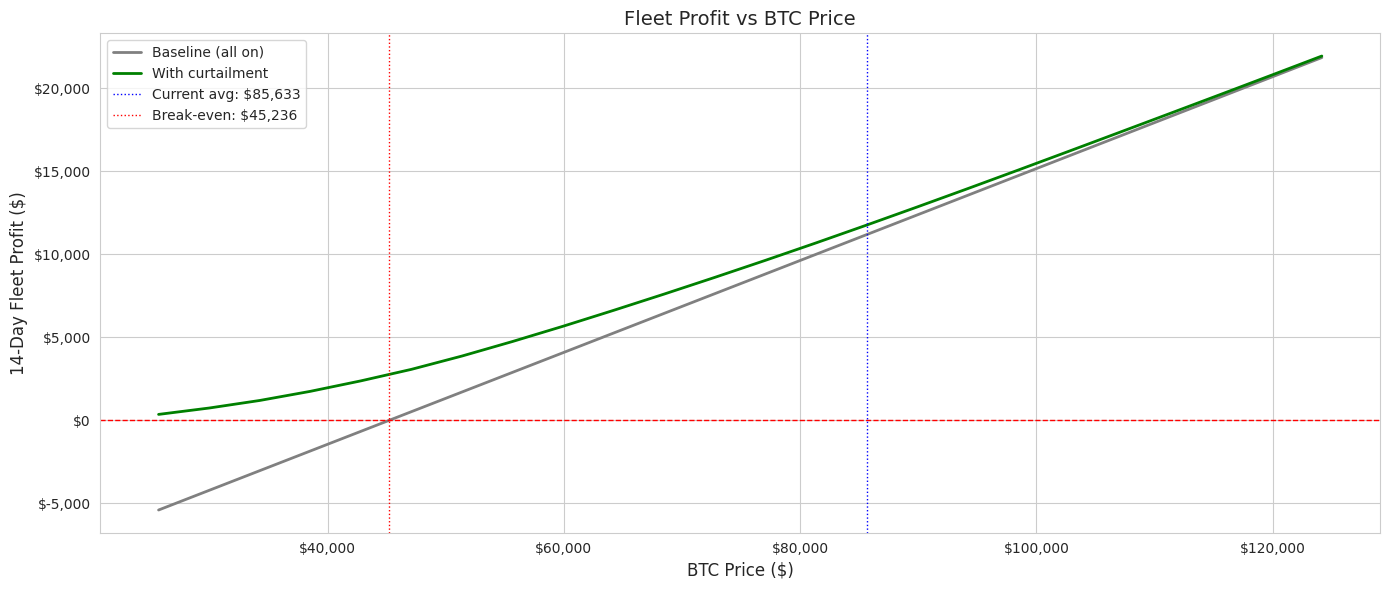

In [29]:
# --- BTC price sensitivity curve ---
btc_multipliers = np.arange(0.3, 1.5, 0.05)
btc_profits = []
btc_curtailed_profits = []

for mult in btc_multipliers:
    adj_rev = miner_hour['revenue'] * mult
    adj_profit = adj_rev - miner_hour['cost']
    btc_profits.append(adj_profit.sum())
    btc_curtailed_profits.append(adj_profit[adj_profit >= 0].sum())

fig, ax = plt.subplots(figsize=(14, 6))
btc_prices = avg_btc_price * btc_multipliers
ax.plot(btc_prices, btc_profits, label='Baseline (all on)', color='gray', lw=2)
ax.plot(btc_prices, btc_curtailed_profits, label='With curtailment', color='green', lw=2)
ax.axhline(0, color='red', ls='--', lw=1)
ax.axvline(avg_btc_price, color='blue', ls=':', lw=1, label=f'Current avg: ${avg_btc_price:,.0f}')
ax.axvline(break_even_btc, color='red', ls=':', lw=1, label=f'Break-even: ${break_even_btc:,.0f}')
ax.set_xlabel('BTC Price ($)')
ax.set_ylabel('14-Day Fleet Profit ($)')
ax.set_title('Fleet Profit vs BTC Price')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [30]:
# --- Which miners to retire first if BTC drops 30%? ---
btc_drop = 0.70  # 30% drop
adj_revenue_30 = miner_hour['revenue'] * btc_drop
adj_profit_30 = adj_revenue_30 - miner_hour['cost']

miner_hour_30 = miner_hour.copy()
miner_hour_30['adj_profit'] = adj_profit_30

retire_analysis = miner_hour_30.groupby('miner_id').agg(
    total_profit=('adj_profit', 'sum'),
    pct_unprofitable=('adj_profit', lambda x: (x < 0).mean() * 100),
    avg_efficiency=('efficiency', 'mean'),
    model=('model', 'first')
).sort_values('total_profit').reset_index()

n_losers = (retire_analysis['total_profit'] < 0).sum()
print(f'With 30% BTC price drop: {n_losers} miners would be net unprofitable over 14 days')
print(f'\nFirst 15 miners to retire (biggest losers):')
print(retire_analysis[['miner_id', 'model', 'avg_efficiency', 'total_profit', 'pct_unprofitable']]
      .head(15).to_string(index=False, float_format='%.2f'))

# Summary by model
print(f'\nRetirement priority by model:')
model_retire = retire_analysis[retire_analysis['total_profit'] < 0].groupby('model').agg(
    count=('miner_id', 'count'),
    avg_loss=('total_profit', 'mean')
).sort_values('avg_loss')
print(model_retire.to_string())

With 30% BTC price drop: 0 miners would be net unprofitable over 14 days

First 15 miners to retire (biggest losers):
miner_id model  avg_efficiency  total_profit  pct_unprofitable
MNR-0115  M56S           25.65          0.06             40.77
MNR-0120  M56S           25.65          0.06             40.77
MNR-0114  M56S           25.65          0.08             40.77
MNR-0116  M56S           25.64          0.08             40.77
MNR-0111  M56S           25.65          0.09             40.77
MNR-0117  M56S           25.63          0.10             40.77
MNR-0112  M56S           25.64          0.11             40.77
MNR-0119  M56S           25.65          0.12             40.77
MNR-0113  M56S           25.65          0.14             40.77
MNR-0118  M56S           25.65          0.17             40.77
MNR-0145 S19XP           24.87          1.70             39.58
MNR-0065 S19XP           23.92          4.18             36.61
MNR-0088 S19XP           21.75          7.39             54.17


## 8. Key Findings & Recommendations

In [31]:
# --- Quantify high-price event on days 8-9 ---
# Identify the high electricity price period
fleet_hr_copy = fleet_hr.copy()
fleet_hr_copy['day_num'] = (fleet_hr_copy['hour'] - fleet_hr_copy['hour'].min()).dt.days + 1

# Days 8-9
high_price_mask = fleet_hr_copy['day_num'].isin([8, 9])
baseline_d89 = fleet_hr_copy.loc[high_price_mask, 'profit'].sum()

# Naive curtailment on those days
compare3_copy = compare3.copy()
compare3_copy['day_num'] = (compare3_copy['hour'] - compare3_copy['hour'].min()).dt.days + 1
high_price_mask2 = compare3_copy['day_num'].isin([8, 9])
naive_d89 = compare3_copy.loc[high_price_mask2, 'naive_profit'].sum()
savings_d89 = naive_d89 - baseline_d89

print(f'Days 8-9 baseline profit  : ${baseline_d89:>10,.2f}')
print(f'Days 8-9 curtailed profit : ${naive_d89:>10,.2f}')
print(f'Savings during high-price : ${savings_d89:>10,.2f}')

Days 8-9 baseline profit  : $    770.22
Days 8-9 curtailed profit : $  1,216.67
Savings during high-price : $    446.45


In [32]:
# --- Decision rules for operators ---
# For each model, find the electricity rate threshold above which they're unprofitable
# At the average hash_price, break-even when:
#   hash_price / 24 = efficiency * elec_rate / 1000
#   elec_rate = (hash_price * 1000) / (24 * efficiency)

avg_hash_price = econ['hash_price_usd_th_day'].mean()

model_specs = registry.groupby('model').agg(
    count=('miner_id', 'count'),
    nom_efficiency=('nominal_efficiency_wth', 'mean'),
    nom_hashrate=('nominal_hashrate_th', 'mean'),
    nom_power=('nominal_power_w', 'mean')
).reset_index()

# Actual average efficiency from telemetry
actual_eff = df.groupby('model')['efficiency_wth'].mean().reset_index()
actual_eff.columns = ['model', 'actual_efficiency']
model_specs = model_specs.merge(actual_eff, on='model')

model_specs['max_elec_rate'] = (avg_hash_price * 1000) / (24 * model_specs['actual_efficiency'])
model_specs = model_specs.sort_values('actual_efficiency')

print(f'Average hash price: ${avg_hash_price:.5f}/TH/day')
print(f'\nDecision Rules — Shut down when electricity rate exceeds:')
print(f'{"Model":<10} {"Count":>5} {"Eff (W/TH)":>10} {"Max $/kWh":>10}')
print('-' * 40)
for _, row in model_specs.iterrows():
    print(f'{row["model"]:<10} {row["count"]:>5} {row["actual_efficiency"]:>10.1f} '
          f'{row["max_elec_rate"]:>10.4f}')

Average hash price: $0.04487/TH/day

Decision Rules — Shut down when electricity rate exceeds:
Model      Count Eff (W/TH)  Max $/kWh
----------------------------------------
S21           75       17.6     0.1060
M63           30       18.6     0.1005
S19XP         65       21.8     0.0857
M56S          10       25.6     0.0729


In [33]:
# === EXECUTIVE SUMMARY ===

print('=' * 60)
print('   CURTAILMENT OPTIMIZATION — EXECUTIVE SUMMARY')
print('=' * 60)
print()
print(f'Fleet: {n_miners} miners across {registry.model.nunique()} models')
print(f'Period: 14 days ({fleet_hr.hour.min().date()} to {fleet_hr.hour.max().date()})')
print()
print(f'--- Financial Summary (14 days) ---')
print(f'  Baseline profit (all-on 24/7) : ${baseline_total:>12,.2f}')
print(f'  Naive curtailment profit      : ${naive_total:>12,.2f}  (saves ${naive_total - baseline_total:>10,.2f})')
print(f'  Hysteresis curtailment profit : ${hyst_total_profit:>12,.2f}  (saves ${hyst_total_profit - baseline_total:>10,.2f})')
print(f'  DP-Optimal profit             : ${opt_net_profit:>12,.2f}  (saves ${opt_net_profit - baseline_total:>10,.2f})')
print()
print(f'--- Projected Savings ---')
best_savings = max(naive_total, hyst_total_profit, opt_net_profit) - baseline_total
print(f'  Best strategy savings/day     : ${best_savings/14:>10,.2f}')
print(f'  Best strategy savings/month   : ${best_savings/14*30:>10,.2f}')
print(f'  Best strategy savings/year    : ${best_savings/14*365:>10,.2f}')
print()
print(f'--- Switching Events ---')
print(f'  Naive  : {naive_switches:>6,} events ({naive_switches/180/14:.1f}/miner/day)')
print(f'  Hysteresis: {hyst_switches:>6,} events ({hyst_switches/180/14:.1f}/miner/day)')
print(f'  Optimal: {int(n_switch_events):>6,} events ({n_switch_events/180/14:.1f}/miner/day)')
print()
print(f'--- Key Insights ---')
print(f'  Fleet break-even BTC price: ${break_even_btc:,.0f} '
      f'({(1-break_even_multiplier)*100:.0f}% below current ${avg_btc_price:,.0f})')
print(f'  During high-price days 8-9, curtailment would have saved ${savings_d89:,.2f}')
print(f'  {n_losers} miners become net-unprofitable if BTC drops 30%')
print()
print(f'--- Recommendation ---')
print(f'  Deploy merit-order curtailment with hysteresis as the')
print(f'  `nextHourShouldMine` logic in MiningOS.')
print(f'  Rank miners by efficiency; shut down worst first when')
print(f'  electricity_rate > break-even threshold per model.')
print(f'  Add 30-min hysteresis to avoid excessive cycling.')
print(f'  Model retirement priority: M56S > S19XP > M63 > S21')

   CURTAILMENT OPTIMIZATION — EXECUTIVE SUMMARY

Fleet: 180 miners across 4 models
Period: 14 days (2026-04-09 to 2026-04-22)

--- Financial Summary (14 days) ---
  Baseline profit (all-on 24/7) : $   11,189.10
  Naive curtailment profit      : $   11,764.09  (saves $    574.99)
  Hysteresis curtailment profit : $   11,104.44  (saves $    -84.65)
  DP-Optimal profit             : $   11,247.73  (saves $     58.63)

--- Projected Savings ---
  Best strategy savings/day     : $     41.07
  Best strategy savings/month   : $  1,232.13
  Best strategy savings/year    : $ 14,990.93

--- Switching Events ---
  Naive  :  3,944 events (1.6/miner/day)
  Hysteresis:      5 events (0.0/miner/day)
  Optimal:    416 events (0.2/miner/day)

--- Key Insights ---
  Fleet break-even BTC price: $45,236 (47% below current $85,633)
  During high-price days 8-9, curtailment would have saved $446.45
  0 miners become net-unprofitable if BTC drops 30%

--- Recommendation ---
  Deploy merit-order curtailment w